In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.morphology import h_minima

In [2]:
path = r"final_choice/"

tif_lefttop = path + r"R5_44BN1.TIF"
tif_righttop = path + r"R5_44BN2.TIF"
tif_leftbottom = path + r"R5_44BZ1.TIF"
tif_rightbottom = path + r"R5_44BZ2.TIF"

with rasterio.open(tif_lefttop) as src_lt, rasterio.open(tif_righttop) as src_rt, rasterio.open(tif_leftbottom) as src_lb, rasterio.open(tif_rightbottom) as src_rb:
    left_top = src_lt.read(1, masked=True).astype(float).filled(np.nan)
    right_top = src_rt.read(1, masked=True).astype(float).filled(np.nan)
    left_bottom = src_lb.read(1, masked=True).astype(float).filled(np.nan)
    right_bottom = src_rb.read(1, masked=True).astype(float).filled(np.nan)

    print("left_top shape:", left_top.shape)
    print("right_top shape:", right_top.shape)
    print("left_bottom shape:", left_bottom.shape)
    print("right_bottom shape:", right_bottom.shape)

    elevation = np.block([[left_top, right_top], [left_bottom, right_bottom]])
    elevation[~np.isfinite(elevation)] = np.nan

    print("Merged array shape:", elevation.shape)
    print("Height / rows:", elevation.shape[0])
    print("Width / columns:", elevation.shape[1])
    print("Number of bands:", src_lt.count)
    print("Resolution:", src_lt.res)
    print("Bounds:", src_lt.bounds)
    print("CRS:", src_lt.crs)

print("Min:", np.nanmin(elevation))
print("Max:", np.nanmax(elevation))
print("Mean:", np.nanmean(elevation))
print("Total number of pixels:", elevation.size)

left_top shape: (1250, 1000)
right_top shape: (1250, 1000)
left_bottom shape: (1250, 1000)
right_bottom shape: (1250, 1000)
Merged array shape: (2500, 2000)
Height / rows: 2500
Width / columns: 2000
Number of bands: 1
Resolution: (5.0, 5.0)
Bounds: BoundingBox(left=110000.0, bottom=418750.0, right=115000.0, top=425000.0)
CRS: EPSG:28992
Min: -3.4235808849334717
Max: 119.20974731445312
Mean: 2.0693964136580254
Total number of pixels: 5000000


In [3]:
interval_size = 10 #elevation intervals
intervals = np.arange(-10, 90 + interval_size, interval_size) 

valid = elevation[np.isfinite(elevation)]
hist, bin_edges = np.histogram(valid, bins=intervals)

print("Elevation intervals:")
for i in range(len(hist)):
    if hist[i] > 0:
        print(f"Interval {intervals[i]} - {intervals[i+1]}: {hist[i]} pixels")

Elevation intervals:
Interval -10 - 0: 298264 pixels
Interval 0 - 10: 3179346 pixels
Interval 10 - 20: 82282 pixels
Interval 20 - 30: 2441 pixels
Interval 30 - 40: 905 pixels
Interval 40 - 50: 207 pixels
Interval 50 - 60: 168 pixels
Interval 60 - 70: 159 pixels
Interval 70 - 80: 75 pixels
Interval 80 - 90: 114 pixels


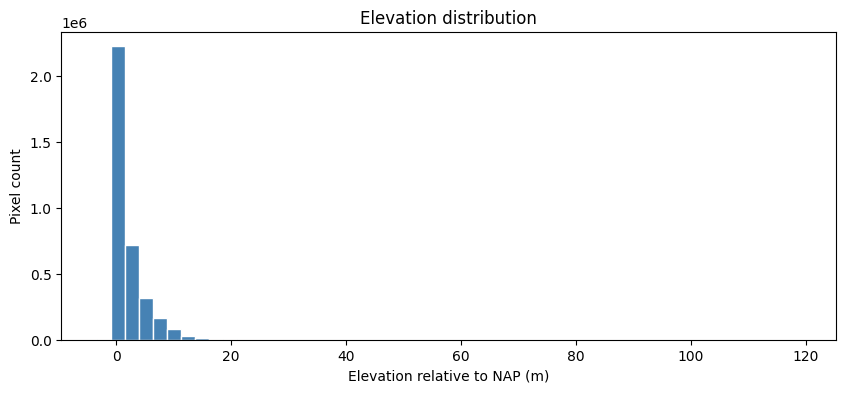

In [4]:
plt.figure(figsize=(10, 4))
plt.hist(valid, bins=50, color="steelblue", edgecolor="white")
plt.title("Elevation distribution")
plt.xlabel("Elevation relative to NAP (m)")
plt.ylabel("Pixel count")
plt.show() #distribution of elevation values in the whole tif file data.

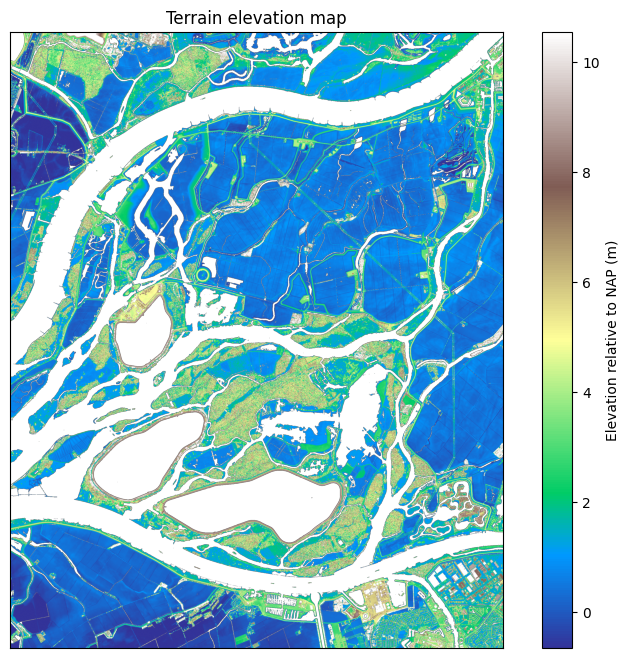

In [5]:
plt.figure(figsize=(10, 8)) #visualization of the elevation data as a terrain map.
vmin, vmax = np.nanpercentile(elevation, [2, 98])

plt.imshow(elevation, cmap="terrain", vmin=vmin, vmax=vmax)
plt.colorbar(label="Elevation relative to NAP (m)")
plt.title("Terrain elevation map")
plt.xticks([])
plt.yticks([])
plt.show()

#cropping region of the elevation data for limited memory usage and faster processing.
row_start, row_end = 9500, 13000 #vertical range of crop
col_start, col_end = 4000, 7000 #horizontal range of crop

crop = elevation[row_start:row_end, col_start:col_end]

print("Crop shape:", crop.shape) #3000x3000 is okay, ~5000x5000 starts to take a long time
print("Crop min:", np.nanmin(crop))
print("Crop max:", np.nanmax(crop))
print("Crop mean:", np.nanmean(crop))

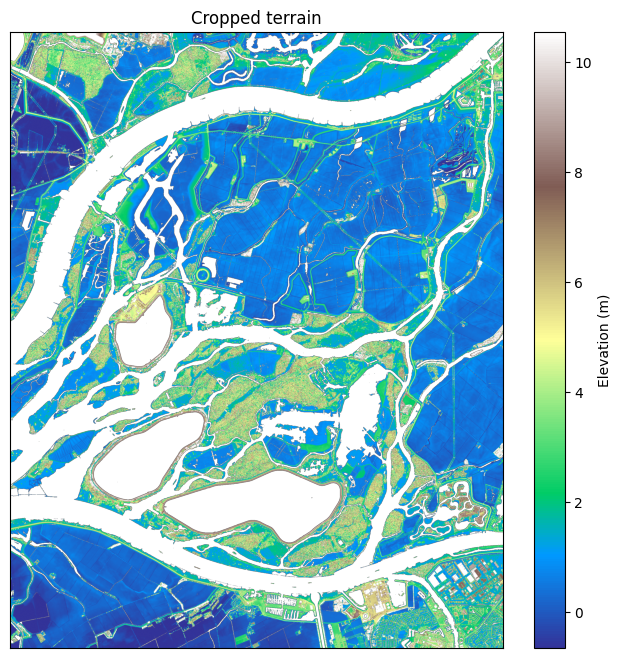

In [6]:
plt.figure(figsize=(8, 8)) #visualization of the cropped elevation data as a terrain map.
crop = elevation
vmin_crop, vmax_crop = np.nanpercentile(crop, [2, 98])

plt.imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
plt.colorbar(label="Elevation (m)")
plt.title("Cropped terrain")
plt.xticks([])
plt.yticks([])
plt.show()

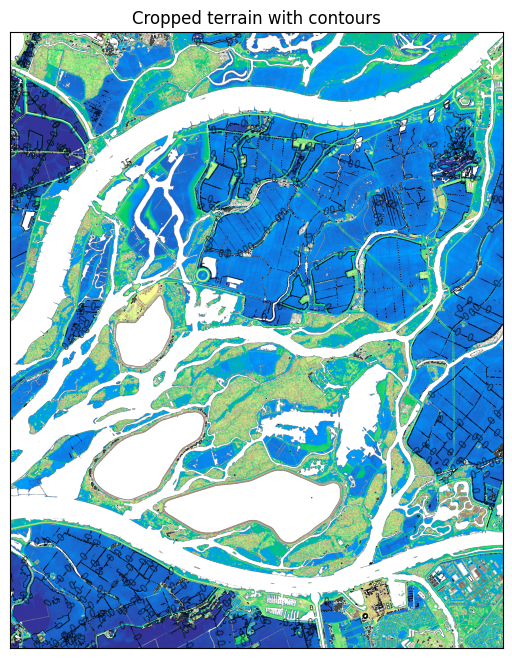

In [7]:
plt.figure(figsize=(8, 8)) #visualization of the cropped elevation data as a terrain map with contours.
vmin_crop, vmax_crop = np.nanpercentile(crop, [2, 98])

plt.imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
contours = plt.contour(crop, levels=10, colors="black", linewidths=0.5, alpha=0.7) #adding black contour lines to the terrain map (also shows trees well)
plt.clabel(contours, inline=True, fontsize=7)
plt.title("Cropped terrain with contours")
plt.xticks([])
plt.yticks([])
plt.show()

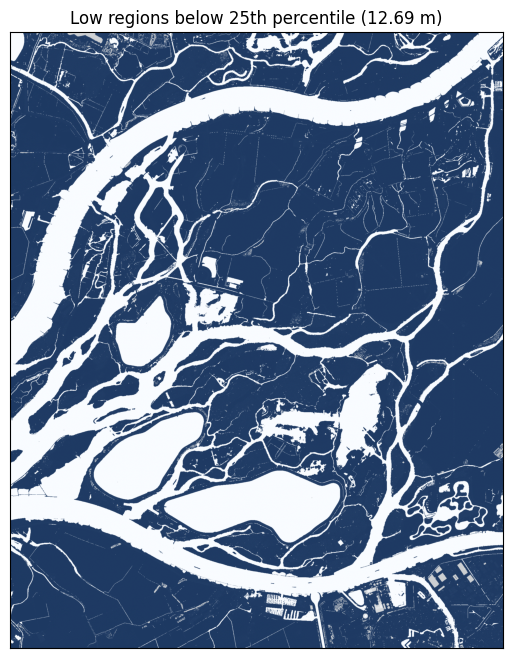

In [8]:
low_threshold = np.nanpercentile(crop, 99) #is 25th percentile a good threshold for low elevation?
low_regions = (crop <= low_threshold)

plt.figure(figsize=(8, 8)) #visualization of the low elevation regions in the cropped area (below 25th percentile).
plt.imshow(crop, cmap="Greys_r", alpha=0.7)
plt.imshow(low_regions, cmap="Blues", alpha=0.7)
plt.title(f"Low regions below 25th percentile ({low_threshold:.2f} m)")
plt.xticks([])
plt.yticks([])
plt.show()

In [16]:
def find_local_minima_simple(Z): #finding local minima by comparing each pixel to its 4 neighbors (up, down, left, right)
    rows, cols = Z.shape
    minima = []

    for r in range(1, rows - 1): #ignoring borders to avoid out-of-bounds errors
        for c in range(1, cols - 1):
            val = Z[r, c] #current pixel value
            if not np.isfinite(val):
                continue #skip NaN values
            #check if current pixel is less than its 4 neighbors
            if (
                val < Z[r - 1, c]
                and val < Z[r + 1, c]
                and val < Z[r, c - 1]
                and val < Z[r, c + 1]
            ):
                minima.append((r, c, val))

    return np.array(minima, dtype=float) if minima else np.empty((0, 3))

from scipy.ndimage import minimum_filter
def find_meaningful_minima(Z, sigma=1, h_threshold=0.5):
    Z_smooth = gaussian_filter(Z, sigma=sigma)
    local_min = minimum_filter(Z_smooth, size=5)
    is_min = (Z_smooth == local_min)
    # depth filter: min must be h_threshold below its neighborhood max
    from scipy.ndimage import maximum_filter
    local_max = maximum_filter(Z_smooth, size=20)
    deep_enough = (local_max - Z_smooth) >= h_threshold
    return np.argwhere(is_min & deep_enough)

In [17]:
interpolate_value = np.nanmin(crop)-1.0
print("Interpolate value for NaNs:", interpolate_value)

Interpolate value for NaNs: -4.423580884933472


In [18]:
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=np.min(crop_filled))

#minima = find_local_minima_simple(crop_filled)
minima = find_meaningful_minima(crop_filled)
print(f"Found {len(minima)} local minima in crop")

Found 16026 local minima in crop


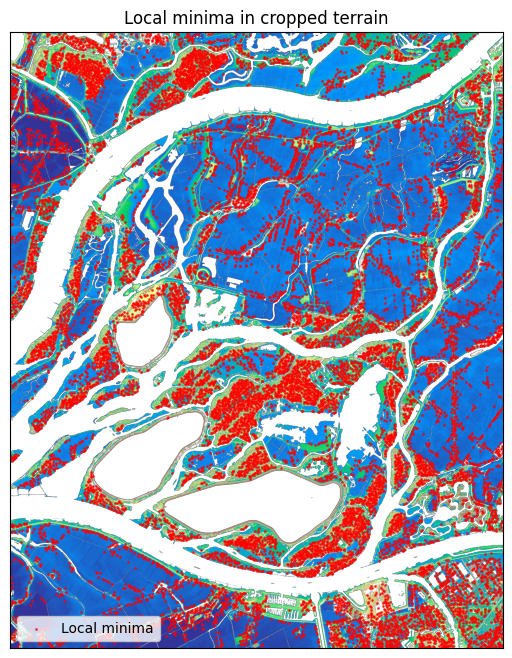

In [19]:
plt.figure(figsize=(8, 8)) #visualization of the local minima on the cropped terrain map.
plt.imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)

if len(minima) > 0:
    plt.scatter(minima[:, 1], minima[:, 0], c="red", s=1, alpha=0.7, label="Local minima")
    plt.legend()

plt.title("Local minima in cropped terrain")
plt.xticks([])
plt.yticks([])
plt.show()

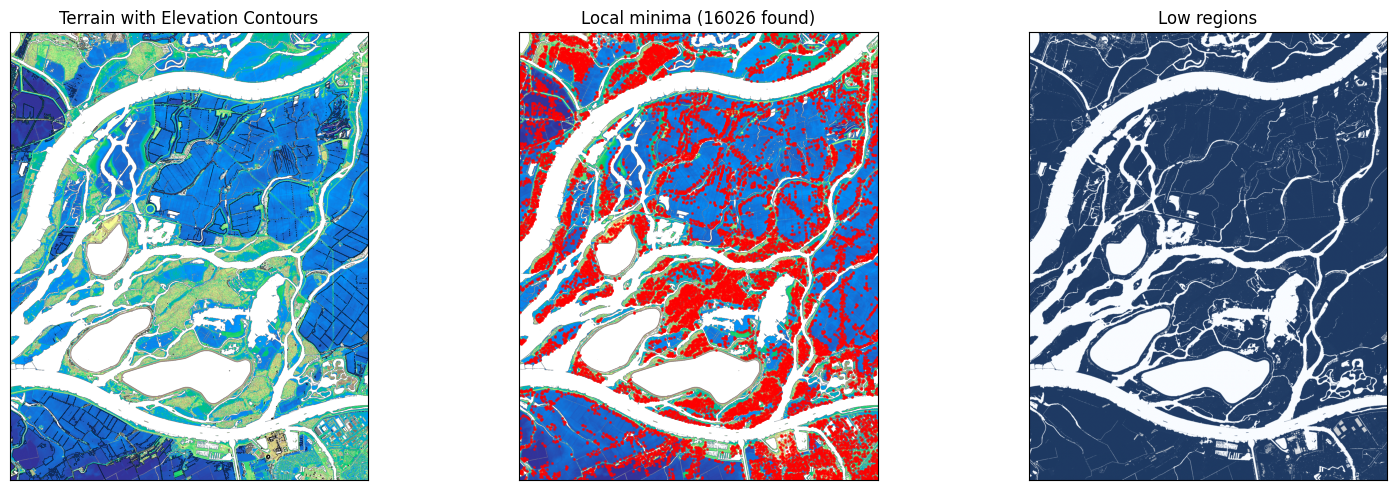

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#terrain with contours
axes[0].imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
axes[0].contour(crop, levels=10, colors='black', linewidths=0.5, alpha=0.5)
axes[0].set_title("Terrain with Elevation Contours")

#Local Minima
axes[1].imshow(crop, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
if len(minima) > 0:
    axes[1].scatter(minima[:, 1], minima[:, 0], c="red", s=1, alpha=0.7)
axes[1].set_title(f"Local minima ({len(minima)} found)")

#Low elevation regions
axes[2].imshow(crop, cmap="Greys_r", alpha=0.7)
axes[2].imshow(low_regions, cmap="Blues", alpha=0.7)
axes[2].set_title("Low regions")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
def flood_fill(terrain_map, start, start_level, threshold=0.0):
    rows, cols = terrain_map.shape
    
    visited = np.zeros_like(terrain_map, dtype=bool)
    to_visit = [start]
    basin_points = []
    print(f"Starting flood fill from {start} with threshold {threshold}m")
    print(f"Elevation at start point: {start_level:.2f} m")
    while to_visit:
        r, c = to_visit.pop()
        if visited[r, c]:
            continue
        visited[r, c] = True
        basin_points.append((r, c))

        # Check 8 neighbors
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols and not visited[nr, nc]:
                neighbor_elev = terrain_map[nr, nc]
                if np.isfinite(neighbor_elev) and neighbor_elev <= start_level + threshold:
                    to_visit.append((nr, nc))
                else:
                    #print(f"Skipping neighbor {(nr, nc)} with elevation {neighbor_elev:.2f} >= {start_level:.2f} + {threshold:.2f}")
                    pass

    return basin_points

In [ ]:
thresholds = []
for percentile in range(10, 101, 10): #experimenting with different elevation thresholds to see how they affect the identified low elevation regions and local minima.
    low_threshold = np.nanpercentile(crop_filled, percentile) #is 25th percentile a good threshold for low elevation?
    print(f"{percentile}% elevation threshold: {low_threshold:.2f} m")
    thresholds.append(low_threshold)


In [ ]:
def plot_flood_fill_result(Z, basin_points, origin):
    plt.figure(figsize=(8, 8))
    plt.imshow(Z, cmap="terrain", vmin=vmin_crop, vmax=vmax_crop)
    
    if basin_points:
        basin_points = np.array(basin_points)
        plt.scatter(basin_points[:, 1], basin_points[:, 0], c="purple", s=1, alpha=0.7, label="Basin points")
    
    plt.scatter(origin[1], origin[0], c="red", s=50, marker="X", label="Origin")
    plt.legend()
    plt.title("Flood fill result")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[5] #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.

basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[6] #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.

basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[6]+0.7 #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.


basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[6]+0.8 #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.


basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[6]+0.9 #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.


basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[6]+1.0 #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.


basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[6]+1.1 #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.


basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)

In [ ]:
origin_level_up_position = (2000, 500) #example position of the origin level up point (can be adjusted based on actual data) 
crop_filled = crop.copy()
crop_filled = np.nan_to_num(crop_filled, nan=interpolate_value)
current_level_map = np.full(crop_filled.shape, -10) #initialize a map to store the current level of each pixel (NaN means unvisited)

origin_level = thresholds[7] #using the first threshold (10th percentile) as the origin level for flood fill, but can experiment with others too.

basin_points = flood_fill(crop_filled, origin_level_up_position, origin_level) #example threshold for how much elevation increase is allowed to still be considered part of the same basin (can be adjusted based on actual data)
print(f"Flood fill found {len(basin_points)} points in the basin starting from {origin_level_up_position} with threshold 0.5m")
plot_flood_fill_result(crop_filled, basin_points, origin_level_up_position)